ЛИНЕЙНЫЙ ДИСКРИМИНАНТНЫЙ АНАЛИЗ (LDA) С СРАВНЕНИЕМ С БИБЛИОТЕКОЙ

Выберите режим запуска:
1. Основной режим с меню (рекомендуется)
2. Быстрый тест
3. Просто тест на оригинальном примере
ЛИНЕЙНЫЙ ДИСКРИМИНАНТНЫЙ АНАЛИЗ (LDA) - УЛУЧШЕННАЯ ВЕРСИЯ

МЕНЮ ВЫБОРА ТЕСТА
1. Тест на оригинальном примере с предприятиями
2. Тест на датасете диабета
3. Настройки визуализации
4. Включить/выключить сравнение с библиотекой
5. Выход

Настройки для теста с предприятиями:
ТЕСТ: ОРИГИНАЛЬНЫЙ ПРИМЕР С ПРЕДПРИЯТИЯМИ
Класс 1: Передовые предприятия (4 объекта)
Класс 2: Отстающие предприятия (5 объектов)
Тестовые объекты: 3 предприятия для классификации
ЛИНЕЙНЫЙ ДИСКРИМИНАНТНЫЙ АНАЛИЗ (LDA)
Класс 1: 4 объектов
Класс 2: 5 объектов
Тестовые объекты: 3
Количество признаков: 3

----------------------------------------
СРЕДНИЕ ВЕКТОРЫ:
Класс 1 (Передовые предприятия): [168.905  14.048  18.332]
Класс 2 (Отстающие предприятия): [45.791  4.778 10.758]

Тип ковариации: Несмещенная (n-1)

КОЭФФИЦИЕНТЫ ДИСКРИМИНАНТНОЙ ФУ

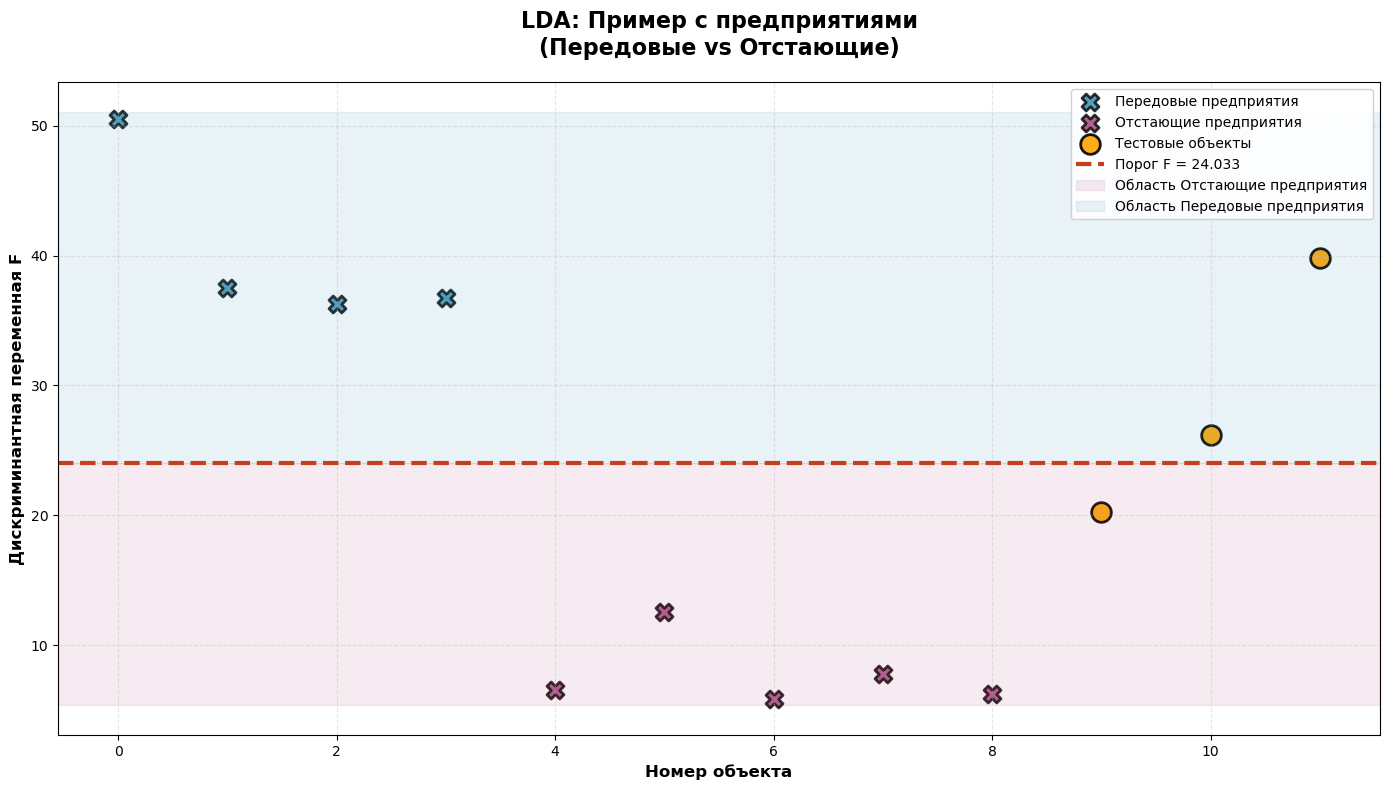


МЕНЮ ВЫБОРА ТЕСТА
1. Тест на оригинальном примере с предприятиями
2. Тест на датасете диабета
3. Настройки визуализации
4. Включить/выключить сравнение с библиотекой
5. Выход

НАСТРОЙКИ ТЕСТА ДИАБЕТА
АНАЛИЗ ДАТАСЕТА ДИАБЕТА С ПОМОЩЬЮ LDA
Загрузка данных из diabetes.csv...
Используем все данные: 768 строк

Общая статистика:
Размер датасета: (768, 9)

Распределение классов:
  Нет диабета: 500 объектов (65.1%)
  Диабет: 268 объектов (34.9%)

Используемые признаки (4):
  F1: Glucose
  F2: BMI
  F3: Age
  F4: Pregnancies

Распределение по классам:
  Класс 0 (нет диабета): 500 объектов
  Класс 1 (диабет): 268 объектов

Разделение данных (70% обучение / 30% тест):
  Класс 0: 350 обучение / 150 тест
  Класс 1: 187 обучение / 81 тест
  Всего тестовых: 231 объектов

ПРИМЕНЕНИЕ LDA
ЛИНЕЙНЫЙ ДИСКРИМИНАНТНЫЙ АНАЛИЗ (LDA)
Класс 1: 350 объектов
Класс 2: 187 объектов
Тестовые объекты: 231
Количество признаков: 4

----------------------------------------
СРЕДНИЕ ВЕКТОРЫ:
Класс 1 (Нет диабета): [-0.  0

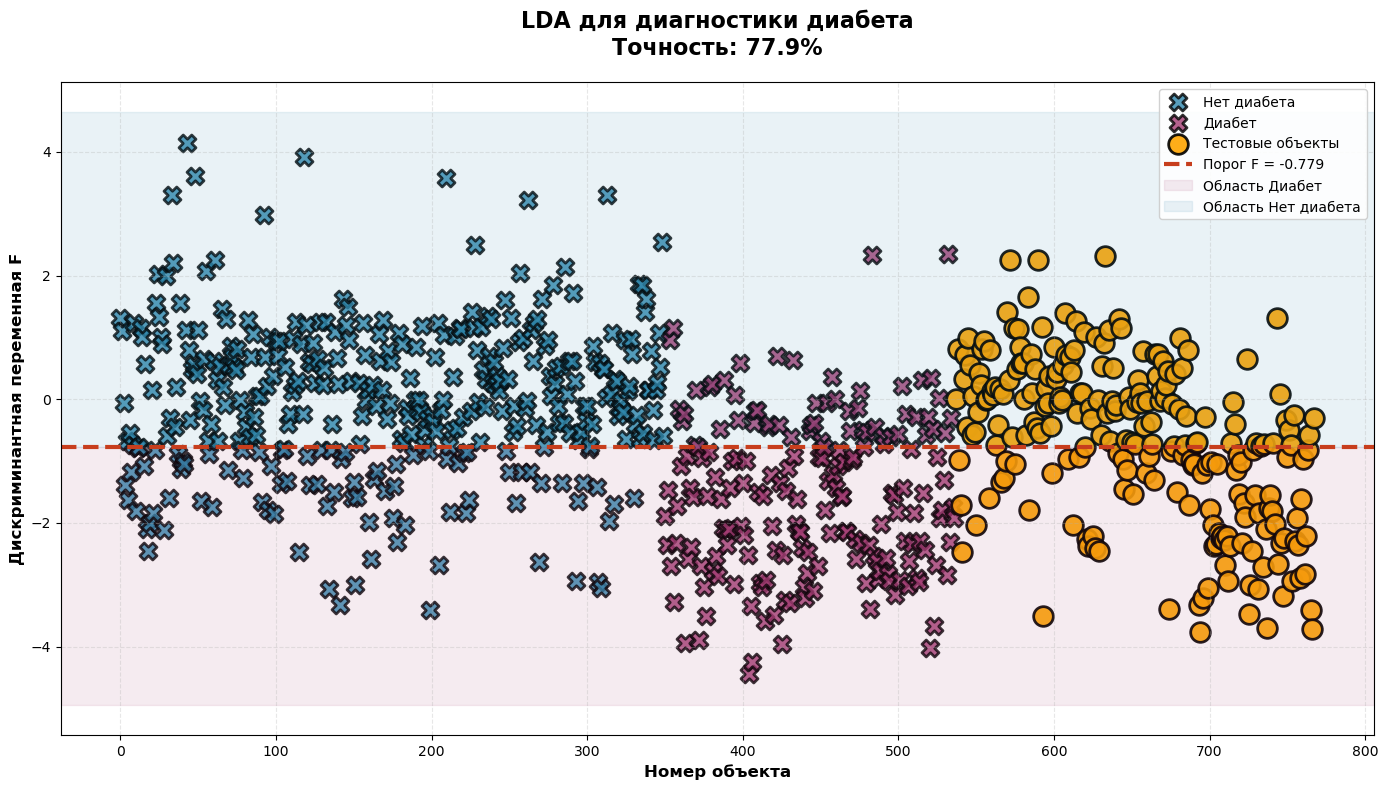


Тест завершен успешно!
Использовано образцов: 768
Точность: 77.92%

МЕНЮ ВЫБОРА ТЕСТА
1. Тест на оригинальном примере с предприятиями
2. Тест на датасете диабета
3. Настройки визуализации
4. Включить/выключить сравнение с библиотекой
5. Выход

Неверный выбор. Пожалуйста, выберите 1, 2, 3, 4 или 5.

МЕНЮ ВЫБОРА ТЕСТА
1. Тест на оригинальном примере с предприятиями
2. Тест на датасете диабета
3. Настройки визуализации
4. Включить/выключить сравнение с библиотекой
5. Выход

Выход из программы.

ВЫВОДЫ О LDA:
1. LDA создает линейную границу между классами
2. Дискриминантная функция F показывает 'расстояние' до границы
3. Порог F_all разделяет пространство признаков
4. Коэффициенты показывают важность признаков
5. Метод эффективен для бинарной классификации
6. Нормализация данных улучшает результаты
7. Сравнение с scikit-learn помогает проверить корректность реализации


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# ОСНОВНАЯ ФУНКЦИЯ LDA
# ============================================================================
def lda_algorithm(x1, x2, x0, class1_name="Класс 1", class2_name="Класс 2", 
                  use_unbiased_cov=True, verbose=True):
    """
    Алгоритм LDA для двух классов
    
    Параметры:
    -----------
    x1, x2 : массивы numpy
        Обучающие данные для классов 1 и 2
    x0 : массив numpy
        Тестовые данные
    class1_name, class2_name : str
        Названия классов для вывода
    use_unbiased_cov : bool
        True - несмещенная ковариация (n-1)
        False - смещенная ковариация (n)
    verbose : bool
        Выводить подробную информацию
    """
    if verbose:
        print("=" * 60)
        print("ЛИНЕЙНЫЙ ДИСКРИМИНАНТНЫЙ АНАЛИЗ (LDA)")
        print("=" * 60)
    
    # Проверка входных данных
    if len(x1) == 0 or len(x2) == 0:
        raise ValueError("Один из классов пуст!")
    
    if x1.shape[1] != x2.shape[1] or x1.shape[1] != x0.shape[1]:
        raise ValueError("Признаки должны иметь одинаковую размерность!")
    
    n1, n2 = len(x1), len(x2)
    
    if verbose:
        print(f"Класс 1: {n1} объектов")
        print(f"Класс 2: {n2} объектов")
        print(f"Тестовые объекты: {len(x0)}")
        print(f"Количество признаков: {x1.shape[1]}")
    
    # 1. Средние векторы
    sumX1 = x1.mean(axis=0)
    sumX2 = x2.mean(axis=0)
    sumX0 = x0.mean(axis=0)
    
    if verbose:
        print("\n" + "-" * 40)
        print("СРЕДНИЕ ВЕКТОРЫ:")
        print(f"Класс 1 ({class1_name}): {np.round(sumX1, 3)}")
        print(f"Класс 2 ({class2_name}): {np.round(sumX2, 3)}")
    
    # 2. Ковариационные матрицы
    divisor1 = (n1 - 1) if use_unbiased_cov else n1
    divisor2 = (n2 - 1) if use_unbiased_cov else n2
    
    # Векторизованный расчет ковариации
    X1_centered = x1 - sumX1
    X2_centered = x2 - sumX2
    
    s1 = (X1_centered.T @ X1_centered) / divisor1
    s2 = (X2_centered.T @ X2_centered) / divisor2
    
    if verbose:
        print(f"\nТип ковариации: {'Несмещенная (n-1)' if use_unbiased_cov else 'Смещенная (n)'}")
    
    # 3. Общая ковариационная матрица
    S_all = 1/(n1 + n2 - 2) * (n1 * s1 + n2 * s2)
    
    # 4. Обратная матрица
    try:
        SO = np.linalg.inv(S_all)
    except np.linalg.LinAlgError:
        if verbose:
            print("Предупреждение: матрица вырождена, используем псевдообратную")
        SO = np.linalg.pinv(S_all)
    
    # 5. Дискриминантная переменная
    A = SO @ (sumX1 - sumX2)
    
    if verbose:
        print("\nКОЭФФИЦИЕНТЫ ДИСКРИМИНАНТНОЙ ФУНКЦИИ:")
        for i, a in enumerate(A, 1):
            print(f"  Признак {i}: {a:.6f}")
    
    # 6. Находим F
    F1 = x1 @ A
    F2 = x2 @ A
    F0 = x0 @ A
    
    # 7. Среднее F
    F1_mean = F1.mean()
    F2_mean = F2.mean()
    
    # 8. Порог
    F_all_value = 0.5 * (F1_mean + F2_mean)
    
    if verbose:
        print(f"\nСРЕДНИЕ ЗНАЧЕНИЯ F:")
        print(f"Класс 1: {F1_mean:.4f}")
        print(f"Класс 2: {F2_mean:.4f}")
        print(f"Порог классификации: {F_all_value:.4f}")
    
    # 9. Классификация
    classifications = []
    raz = F0 - F_all_value
    
    if verbose:
        print("\n" + "-" * 40)
        print("КЛАССИФИКАЦИЯ ТЕСТОВЫХ ОБЪЕКТОВ:")
    
    for i in range(len(F0)):
        if F1_mean > F2_mean: 
            if raz[i] > 0:
                classification = class1_name
            else: 
                classification = class2_name
        else:
            if raz[i] < 0:
                classification = class1_name
            else: 
                classification = class2_name
        classifications.append(classification)
        
        if verbose and i < 10:  # Показываем только первые 10
            print(f"Объект {i+1}: F = {F0[i]:.4f} → {classification}")
    
    return F1, F2, F0, F_all_value, classifications, A

# ============================================================================
# ФУНКЦИЯ ДЛЯ СРАВНЕНИЯ С БИБЛИОТЕКОЙ SCIKIT-LEARN
# ============================================================================
def compare_with_sklearn(x1, x2, x0, true_labels=None, class1_name="Класс 1", 
                        class2_name="Класс 2", feature_names=None):
    """
    Сравнение собственной реализации LDA с библиотечной версией из scikit-learn
    
    Параметры:
    -----------
    x1, x2 : массивы numpy
        Обучающие данные для классов 1 и 2
    x0 : массив numpy
        Тестовые данные
    true_labels : список или массив
        Истинные метки классов для тестовых данных (если известны)
    class1_name, class2_name : str
        Названия классов
    feature_names : список
        Названия признаков
    """
    print("=" * 80)
    print("СРАВНЕНИЕ С БИБЛИОТЕКОЙ SCIKIT-LEARN")
    print("=" * 80)
    
    # Подготовка данных для scikit-learn
    # Объединяем обучающие данные
    X_train = np.vstack([x1, x2])
    y_train = np.array([0] * len(x1) + [1] * len(x2))  # 0 для класса 1, 1 для класса 2
    
    # Тестовые данные
    X_test = x0
    
    # 1. Обучение собственной модели (получаем коэффициенты)
    print("\n1. СОБСТВЕННАЯ РЕАЛИЗАЦИЯ LDA:")
    print("-" * 40)
    
    # Вызываем нашу функцию для получения коэффициентов
    _, _, _, _, custom_classifications, custom_coef = lda_algorithm(
        x1, x2, x0, class1_name, class2_name, verbose=False
    )
    
    # Преобразуем классификации в числовые метки
    custom_pred = np.array([0 if c == class1_name else 1 for c in custom_classifications])
    
    print(f"Коэффициенты дискриминантной функции:")
    for i, coef in enumerate(custom_coef, 1):
        feature_name = feature_names[i-1] if feature_names else f"Признак {i}"
        print(f"  {feature_name}: {coef:.6f}")
    
    # 2. Обучение scikit-learn модели
    print("\n2. SCIKIT-LEARN РЕАЛИЗАЦИЯ LDA:")
    print("-" * 40)
    
    # Создаем и обучаем модель
    sklearn_lda = LinearDiscriminantAnalysis()
    sklearn_lda.fit(X_train, y_train)
    
    # Прогнозируем
    sklearn_pred = sklearn_lda.predict(X_test)
    
    print(f"Коэффициенты (scikit-learn):")
    for i, coef in enumerate(sklearn_lda.coef_[0], 1):
        feature_name = feature_names[i-1] if feature_names else f"Признак {i}"
        print(f"  {feature_name}: {coef:.6f}")
    
    print(f"\nСвободный член (intercept): {sklearn_lda.intercept_[0]:.6f}")
    print(f"Объясненная дисперсия: {sklearn_lda.explained_variance_ratio_[0]:.4f}")
    
    # 3. Сравнение коэффициентов
    print("\n3. СРАВНЕНИЕ КОЭФФИЦИЕНТОВ:")
    print("-" * 40)
    
    # Нормализуем коэффициенты для сравнения (делаем их сопоставимыми)
    custom_coef_norm = custom_coef / np.linalg.norm(custom_coef)
    sklearn_coef_norm = sklearn_lda.coef_[0] / np.linalg.norm(sklearn_lda.coef_[0])
    
    print("Коэффициенты после нормализации:")
    print(f"{'Признак':15s} | {'Наша реализация':15s} | {'Scikit-learn':15s} | {'Разница':10s}")
    print("-" * 65)
    
    for i in range(len(custom_coef)):
        feature_name = feature_names[i] if feature_names else f"Признак {i+1}"
        diff = abs(custom_coef_norm[i] - sklearn_coef_norm[i])
        print(f"{feature_name:15s} | {custom_coef_norm[i]:15.6f} | {sklearn_coef_norm[i]:15.6f} | {diff:10.6f}")
    
    # Вычисляем косинусное сходство
    cosine_similarity = np.dot(custom_coef_norm, sklearn_coef_norm)
    print(f"\nКосинусное сходство коэффициентов: {cosine_similarity:.6f}")
    
    # 4. Сравнение предсказаний
    print("\n4. СРАВНЕНИЕ ПРЕДСКАЗАНИЙ:")
    print("-" * 40)
    
    print("Тестовые объекты:")
    print(f"{'№':3s} | {'Наша реализация':15s} | {'Scikit-learn':15s} | {'Совпадение':10s}")
    print("-" * 55)
    
    matches = 0
    for i in range(len(X_test)):
        custom_label = class1_name if custom_pred[i] == 0 else class2_name
        sklearn_label = class1_name if sklearn_pred[i] == 0 else class2_name
        match = "✓" if custom_pred[i] == sklearn_pred[i] else "✗"
        
        if custom_pred[i] == sklearn_pred[i]:
            matches += 1
        
        print(f"{i+1:3d} | {custom_label:15s} | {sklearn_label:15s} | {match:^10s}")
    
    agreement = matches / len(X_test) * 100
    print(f"\nСовпадение предсказаний: {matches}/{len(X_test)} ({agreement:.2f}%)")
    
    # 5. Сравнение с истинными метками (если предоставлены)
    if true_labels is not None:
        print("\n5. СРАВНЕНИЕ С ИСТИННЫМИ МЕТКАМИ:")
        print("-" * 40)
        
        # Преобразуем текстовые метки в числовые
        true_numeric = np.array([0 if label == class1_name else 1 for label in true_labels])
        
        # Вычисляем точность
        custom_accuracy = accuracy_score(true_numeric, custom_pred) * 100
        sklearn_accuracy = accuracy_score(true_numeric, sklearn_pred) * 100
        
        print(f"Точность нашей реализации: {custom_accuracy:.2f}%")
        print(f"Точность scikit-learn: {sklearn_accuracy:.2f}%")
        print(f"Разница в точности: {abs(custom_accuracy - sklearn_accuracy):.2f}%")
        
        # Выводим матрицы ошибок
        print(f"\nМатрица ошибок (наша реализация):")
        print(confusion_matrix(true_numeric, custom_pred))
        
        print(f"\nМатрица ошибок (scikit-learn):")
        print(confusion_matrix(true_numeric, sklearn_pred))
        
        if custom_accuracy > sklearn_accuracy:
            print("\n✓ Наша реализация показала лучший результат!")
        elif sklearn_accuracy > custom_accuracy:
            print("\n✓ Scikit-learn показал лучший результат!")
        else:
            print("\n✓ Обе реализации показали одинаковый результат!")
    
    # 6. Анализ различий
    print("\n6. АНАЛИЗ РАЗЛИЧИЙ:")
    print("-" * 40)
    
    print("Возможные причины различий:")
    print("1. Разные методы вычисления ковариационных матриц")
    print("2. Разные способы обработки вырожденных матриц")
    print("3. Разные алгоритмы инверсии матриц")
    print("4. Разные стратегии определения порога классификации")
    print("5. Scikit-learn использует SVD для численной стабильности")
    
    return {
        'custom_coefficients': custom_coef,
        'sklearn_coefficients': sklearn_lda.coef_[0],
        'custom_predictions': custom_pred,
        'sklearn_predictions': sklearn_pred,
        'agreement_percentage': agreement,
        'cosine_similarity': cosine_similarity
    }

# ============================================================================
# ВИЗУАЛИЗАЦИЯ
# ============================================================================
def plot_lda_results(F1, F2, F0, F_all, title, class1_name="Класс 1", 
                    class2_name="Класс 2", show_labels=True, 
                    test_point_color='orange'):
    """
    Визуализация результатов LDA
    
    Параметры:
    -----------
    show_labels : bool
        Показывать подписи над тестовыми точками
    test_point_color : str
        Цвет тестовых точек ('orange', 'green', 'red', 'blue', и т.д.)
    """
    plt.figure(figsize=(14, 8))
    
    # Цвета
    colors = {
        'class1': '#2E86AB',  # Синий
        'class2': '#A23B72',  # Пурпурный
        'test': test_point_color,    # Цвет тестовых точек (можно менять)
        'threshold': '#C73E1D' # Красный
    }
    
    indices_F1 = range(len(F1))                                    
    indices_F2 = range(len(F1), len(F1) + len(F2))                 
    indices_F0 = range(len(F1) + len(F2), len(F1) + len(F2) + len(F0)) 
    
    # Обучение класса 1
    plt.scatter(indices_F1, F1, label=class1_name, marker='X', s=150, 
                linewidth=2, color=colors['class1'], alpha=0.8, edgecolors='black')
    
    # Обучение класса 2
    plt.scatter(indices_F2, F2, label=class2_name, marker='X', s=150, 
                linewidth=2, color=colors['class2'], alpha=0.8, edgecolors='black')
    
    # Тестовые объекты
    plt.scatter(indices_F0, F0, label='Тестовые объекты', marker='o', s=200, 
                color=colors['test'], alpha=0.9, edgecolors='black', linewidth=2)
    
    # Линия границы
    plt.axhline(F_all, color=colors['threshold'], linewidth=3, linestyle='--', 
                label=f'Порог F = {F_all:.3f}')
    
    # Закрашивание областей
    min_val = min(F1.min(), F2.min(), F0.min()) - 0.5
    max_val = max(F1.max(), F2.max(), F0.max()) + 0.5
    
    if F1.mean() > F2.mean():
        plt.axhspan(min_val, F_all, alpha=0.1, color=colors['class2'], 
                    label=f'Область {class2_name}')
        plt.axhspan(F_all, max_val, alpha=0.1, color=colors['class1'], 
                    label=f'Область {class1_name}')
    else:
        plt.axhspan(min_val, F_all, alpha=0.1, color=colors['class1'], 
                    label=f'Область {class1_name}')
        plt.axhspan(F_all, max_val, alpha=0.1, color=colors['class2'], 
                    label=f'Область {class2_name}')
    
    # Подписи тестовых объектов (если включено)
    if show_labels:
        for i, f in enumerate(F0):
            plt.annotate(f'Об.{i+1}\nF={f:.2f}', 
                        (indices_F0[i], f), 
                        textcoords="offset points", 
                        xytext=(0, 15),
                        ha='center', 
                        fontsize=10,
                        fontweight='bold',
                        color='black')
    
    plt.xlabel("Номер объекта", fontsize=12, fontweight='bold')
    plt.ylabel("Дискриминантная переменная F", fontsize=12, fontweight='bold')
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(loc='upper right', fontsize=10, framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# ТЕСТ НА ДАТАСЕТЕ ДИАБЕТА
# ============================================================================
def test_diabetes_dataset(csv_file='diabetes.csv', n_samples='all', 
                         test_point_color='orange', show_labels=True,
                         compare_with_library=True):
    """
    Тестирование LDA на датасете диабета
    
    Параметры:
    -----------
    csv_file : str
        Путь к файлу с данными
    n_samples : str или int
        'all' - все данные
        int - первые N строк (например, 500, 1000)
    test_point_color : str
        Цвет тестовых точек
    show_labels : bool
        Показывать подписи над тестовыми точками
    compare_with_library : bool
        Сравнивать с библиотечной реализацией
    """
    print("=" * 70)
    print("АНАЛИЗ ДАТАСЕТА ДИАБЕТА С ПОМОЩЬЮ LDA")
    print("=" * 70)
    
    # Загрузка данных
    print(f"Загрузка данных из {csv_file}...")
    try:
        diabetes_data = pd.read_csv(csv_file)
    except FileNotFoundError:
        print(f"Ошибка: файл '{csv_file}' не найден!")
        print("Убедитесь, что файл находится в правильной директории.")
        return None
    
    # Определение количества данных
    if n_samples != 'all':
        try:
            n_samples = int(n_samples)
            if n_samples > len(diabetes_data):
                print(f"Предупреждение: запрошено {n_samples} строк, но в файле только {len(diabetes_data)}")
                n_samples = len(diabetes_data)
            diabetes_data = diabetes_data.head(n_samples)
            print(f"Используем первые {n_samples} строк данных")
        except ValueError:
            print("Ошибка: n_samples должен быть 'all' или целым числом")
            return None
    else:
        print(f"Используем все данные: {len(diabetes_data)} строк")
    
    # Проверка колонок
    required_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                       'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
    
    missing_cols = [col for col in required_columns if col not in diabetes_data.columns]
    if missing_cols:
        print(f"Ошибка: отсутствуют колонки: {missing_cols}")
        print(f"Доступные колонки: {list(diabetes_data.columns)}")
        return None
    
    # Статистика
    print(f"\nОбщая статистика:")
    print(f"Размер датасета: {diabetes_data.shape}")
    print(f"\nРаспределение классов:")
    
    class_counts = diabetes_data['Outcome'].value_counts().sort_index()
    for outcome, name in [(0, "Нет диабета"), (1, "Диабет")]:
        if outcome in class_counts.index:
            count = class_counts[outcome]
            perc = count / len(diabetes_data) * 100
            print(f"  {name}: {count} объектов ({perc:.1f}%)")
    
    # Выбор признаков
    features = ['Glucose', 'BMI', 'Age', 'Pregnancies']
    print(f"\nИспользуемые признаки ({len(features)}):")
    for i, feat in enumerate(features, 1):
        print(f"  F{i}: {feat}")
    
    # Подготовка данных
    X = diabetes_data[features].values
    y = diabetes_data['Outcome'].values
    
    # Разделение на классы
    X_class0 = X[y == 0]
    X_class1 = X[y == 1]
    
    print(f"\nРаспределение по классам:")
    print(f"  Класс 0 (нет диабета): {len(X_class0)} объектов")
    print(f"  Класс 1 (диабет): {len(X_class1)} объектов")
    
    # Проверка достаточности данных
    if len(X_class0) < 10 or len(X_class1) < 10:
        print("\nОшибка: слишком мало данных в одном из классов!")
        print("Необходимо минимум 10 объектов в каждом классе для обучения.")
        return None
    
    # Разделение на обучение и тест (70/30)
    split_idx0 = int(0.7 * len(X_class0))
    split_idx1 = int(0.7 * len(X_class1))
    
    x1_train = X_class0[:split_idx0]  # Нет диабета (обучение)
    x1_test = X_class0[split_idx0:]   # Нет диабета (тест)
    
    x2_train = X_class1[:split_idx1]  # Диабет (обучение)
    x2_test = X_class1[split_idx1:]   # Диабет (тест)
    
    x0_test = np.vstack([x1_test, x2_test])
    true_labels = ['Нет диабета'] * len(x1_test) + ['Диабет'] * len(x2_test)
    
    print(f"\nРазделение данных (70% обучение / 30% тест):")
    print(f"  Класс 0: {len(x1_train)} обучение / {len(x1_test)} тест")
    print(f"  Класс 1: {len(x2_train)} обучение / {len(x2_test)} тест")
    print(f"  Всего тестовых: {len(x0_test)} объектов")
    
    # Нормализация
    scaler = StandardScaler()
    x1_train_scaled = scaler.fit_transform(x1_train)
    x2_train_scaled = scaler.transform(x2_train)
    x0_test_scaled = scaler.transform(x0_test)
    
    # Применение LDA
    print("\n" + "=" * 60)
    print("ПРИМЕНЕНИЕ LDA")
    print("=" * 60)
    
    F1, F2, F0, F_all, classifications, coefficients = lda_algorithm(
        x1_train_scaled, x2_train_scaled, x0_test_scaled,
        class1_name="Нет диабета",
        class2_name="Диабет",
        verbose=True
    )
    
    # Оценка точности
    print("\n" + "=" * 40)
    print("РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ:")
    print("=" * 40)
    
    correct = sum(1 for i in range(len(classifications)) 
                 if classifications[i] == true_labels[i])
    accuracy = correct / len(classifications) * 100
    
    print(f"Правильно классифицировано: {correct} из {len(classifications)}")
    print(f"Точность: {accuracy:.2f}%")
    
    # Матрица ошибок
    print(f"\nМАТРИЦА ОШИБОК:")
    conf_matrix = np.zeros((2, 2))
    
    for true, pred in zip(true_labels, classifications):
        true_idx = 0 if true == "Нет диабета" else 1
        pred_idx = 0 if pred == "Нет диабета" else 1
        conf_matrix[true_idx, pred_idx] += 1
    
    print("                     |  Предсказано:      |")
    print("                     | Нет диабета | Диабет |")
    print("---------------------|-------------|--------|")
    print(f"Истинно: Нет диабета |    {int(conf_matrix[0,0]):4d}     |  {int(conf_matrix[0,1]):4d}  |")
    print(f"Истинно: Диабет      |    {int(conf_matrix[1,0]):4d}     |  {int(conf_matrix[1,1]):4d}  |")
    
    # Анализ важности признаков
    print(f"\nАНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ:")
    print("-" * 40)
    
    abs_coeff = np.abs(coefficients)
    total_importance = np.sum(abs_coeff)
    
    for i, (feat, coeff) in enumerate(zip(features, coefficients)):
        importance = abs_coeff[i] / total_importance * 100
        direction = "увеличивает вероятность диабета" if coeff > 0 else "уменьшает вероятность диабета"
        print(f"  {feat:25s}: важность = {importance:5.1f}%, {direction}")
    
    # Сравнение с библиотекой (если включено)
    if compare_with_library:
        comparison_result = compare_with_sklearn(
            x1_train_scaled, x2_train_scaled, x0_test_scaled,
            true_labels=true_labels,
            class1_name="Нет диабета",
            class2_name="Диабет",
            feature_names=features
        )
    
    # Визуализация
    print(f"\nВизуализация...")
    plot_title = f"LDA для диагностики диабета\n"
    if n_samples != 'all':
        plot_title += f"(Использовано {n_samples} строк данных)\n"
    plot_title += f"Точность: {accuracy:.1f}%"
    
    plot_lda_results(
        F1, F2, F0, F_all,
        plot_title,
        class1_name="Нет диабета",
        class2_name="Диабет",
        show_labels=show_labels,
        test_point_color=test_point_color
    )
    
    result = {
        'accuracy': accuracy,
        'conf_matrix': conf_matrix,
        'coefficients': coefficients,
        'features': features,
        'n_samples_used': n_samples if n_samples != 'all' else len(diabetes_data)
    }
    
    if compare_with_library:
        result['comparison'] = comparison_result
    
    return result

# ============================================================================
# ТЕСТ НА ОРИГИНАЛЬНОМ ПРИМЕРЕ
# ============================================================================
def test_original_example(test_point_color='orange', show_labels=True, 
                         compare_with_library=True):
    """
    Тестирование на оригинальном примере с предприятиями
    """
    print("=" * 70)
    print("ТЕСТ: ОРИГИНАЛЬНЫЙ ПРИМЕР С ПРЕДПРИЯТИЯМИ")
    print("=" * 70)
    
    # Данные для примера
    x1 = np.array([
        [224.228, 17.115, 22.981],
        [151.827, 14.904, 21.481],
        [147.313, 13.627, 18.669],
        [152.253, 10.545, 10.199]
    ])

    x2 = np.array([
        [46.757, 4.428, 11.124],
        [29.033, 5.510, 6.091],
        [52.134, 4.214, 11.842],
        [37.050, 5.527, 11.873],
        [63.979, 4.211, 12.860]
    ])

    x0 = np.array([
        [55.451, 9.592, 12.840],
        [78.575, 11.727, 15.535],
        [98.353, 17.572, 20.458]
    ])
    
    print("Класс 1: Передовые предприятия (4 объекта)")
    print("Класс 2: Отстающие предприятия (5 объектов)")
    print("Тестовые объекты: 3 предприятия для классификации")
    
    F1, F2, F0, F_all, classifications, coefficients = lda_algorithm(
        x1, x2, x0, 
        class1_name="Передовые предприятия", 
        class2_name="Отстающие предприятия",
        verbose=True
    )
    
    # Сравнение с библиотекой (если включено)
    if compare_with_library:
        feature_names = ['Прибыль', 'Производительность', 'Инвестиции']
        comparison_result = compare_with_sklearn(
            x1, x2, x0,
            class1_name="Передовые предприятия",
            class2_name="Отстающие предприятия",
            feature_names=feature_names
        )
    
    # Визуализация
    plot_lda_results(
        F1, F2, F0, F_all, 
        "LDA: Пример с предприятиями\n(Передовые vs Отстающие)",
        class1_name="Передовые предприятия",
        class2_name="Отстающие предприятия",
        show_labels=show_labels,
        test_point_color=test_point_color
    )
    
    result = {
        'classifications': classifications,
        'coefficients': coefficients
    }
    
    if compare_with_library:
        result['comparison'] = comparison_result
    
    return result

# ============================================================================
# ГЛАВНАЯ ФУНКЦИЯ
# ============================================================================
def main():
    """
    Главная функция с меню выбора тестов
    """
    print("=" * 80)
    print("ЛИНЕЙНЫЙ ДИСКРИМИНАНТНЫЙ АНАЛИЗ (LDA) - УЛУЧШЕННАЯ ВЕРСИЯ")
    print("=" * 80)
    
    # Настройки по умолчанию
    compare_library = True
    
    while True:
        print("\n" + "=" * 50)
        print("МЕНЮ ВЫБОРА ТЕСТА")
        print("=" * 50)
        print("1. Тест на оригинальном примере с предприятиями")
        print("2. Тест на датасете диабета")
        print("3. Настройки визуализации")
        print("4. Включить/выключить сравнение с библиотекой")
        print("5. Выход")
        
        choice = input("\nВыберите опцию (1-5): ").strip()
        
        if choice == '1':
            # Настройки для теста с предприятиями
            print("\nНастройки для теста с предприятиями:")
            color = input("Цвет тестовых точек (по умолчанию orange): ").strip()
            if not color:
                color = 'orange'
            
            labels_input = input("Показывать подписи над тестовыми точками? (y/n, по умолчанию y): ").strip().lower()
            show_labels = labels_input != 'n'
            
            test_original_example(
                test_point_color=color,
                show_labels=show_labels,
                compare_with_library=compare_library
            )
            
        elif choice == '2':
            # Настройки для теста с диабетом
            print("\n" + "=" * 50)
            print("НАСТРОЙКИ ТЕСТА ДИАБЕТА")
            print("=" * 50)
            
            # Выбор файла
            csv_file = input("Имя CSV файла (по умолчанию diabetes.csv): ").strip()
            if not csv_file:
                csv_file = 'diabetes.csv'
            
            # Выбор количества данных
            n_samples_input = input("Количество данных ('all' или число, например 500, 1000): ").strip()
            if n_samples_input.lower() == 'all' or not n_samples_input:
                n_samples = 'all'
            else:
                try:
                    n_samples = int(n_samples_input)
                    if n_samples <= 0:
                        print("Ошибка: число должно быть положительным!")
                        continue
                except ValueError:
                    print("Ошибка: введите 'all' или число!")
                    continue
            
            # Настройки визуализации
            color = input("Цвет тестовых точек (по умолчанию orange): ").strip()
            if not color:
                color = 'orange'
            
            labels_input = input("Показывать подписи над тестовыми точками? (y/n, по умолчанию y): ").strip().lower()
            show_labels = labels_input != 'n'
            
            # Запуск теста
            result = test_diabetes_dataset(
                csv_file=csv_file,
                n_samples=n_samples,
                test_point_color=color,
                show_labels=show_labels,
                compare_with_library=compare_library
            )
            
            if result:
                print(f"\nТест завершен успешно!")
                print(f"Использовано образцов: {result['n_samples_used']}")
                print(f"Точность: {result['accuracy']:.2f}%")
            
        elif choice == '3':
            # Настройки по умолчанию
            print("\n" + "=" * 50)
            print("НАСТРОЙКИ ВИЗУАЛИЗАЦИИ ПО УМОЛЧАНИЮ")
            print("=" * 50)
            print("Текущие настройки:")
            print("  - Цвет тестовых точек: orange")
            print("  - Подписи над тестовыми точками: включены")
            print("\nЭти настройки можно изменить при запуске каждого теста.")
            
        elif choice == '4':
            compare_library = not compare_library
            status = "включено" if compare_library else "выключено"
            print(f"\nСравнение с библиотекой теперь {status}.")
            
        elif choice == '5':
            print("\nВыход из программы.")
            break
            
        else:
            print("\nНеверный выбор. Пожалуйста, выберите 1, 2, 3, 4 или 5.")
    
    print("\n" + "=" * 80)
    print("ВЫВОДЫ О LDA:")
    print("=" * 80)
    print("1. LDA создает линейную границу между классами")
    print("2. Дискриминантная функция F показывает 'расстояние' до границы")
    print("3. Порог F_all разделяет пространство признаков")
    print("4. Коэффициенты показывают важность признаков")
    print("5. Метод эффективен для бинарной классификации")
    print("6. Нормализация данных улучшает результаты")
    if compare_library:
        print("7. Сравнение с scikit-learn помогает проверить корректность реализации")

# ============================================================================
# АЛЬТЕРНАТИВНЫЙ ЗАПУСК (для быстрого теста)
# ============================================================================
def quick_test():
    """
    Быстрый тест с предустановленными параметрами
    """
    print("=" * 80)
    print("БЫСТРЫЙ ТЕСТ LDA")
    print("=" * 80)
    
    print("\n1. Тестируем на оригинальном примере...")
    test_original_example(
        test_point_color='orange',
        show_labels=True,
        compare_with_library=True
    )
    
    print("\n2. Тестируем на датасете диабета...")
    # Пробуем разные имена файлов
    possible_files = ['diabetes.csv', 'diabetes_dataset.csv', 'diabetes_data.csv', 
                      'diabetes_cleaned.csv', 'data.csv']
    
    file_found = False
    for filename in possible_files:
        try:
            print(f"\nПопытка загрузить {filename}...")
            pd.read_csv(filename).head()
            print(f"Файл {filename} найден!")
            
            result = test_diabetes_dataset(
                csv_file=filename,
                n_samples=500,  # Тестируем на 500 строках
                test_point_color='green',  # Зеленые точки
                show_labels=False,  # Без подписей
                compare_with_library=True
            )
            file_found = True
            break
        except FileNotFoundError:
            continue
    
    if not file_found:
        print("\nНи один из файлов с данными диабета не найден!")
        print("Пожалуйста, убедитесь, что файл diabetes.csv находится в той же папке.")
        print("Или запустите main() для ручной настройки.")

# ============================================================================
# ЗАПУСК ПРОГРАММЫ
# ============================================================================
if __name__ == "__main__":
    print("=" * 80)
    print("ЛИНЕЙНЫЙ ДИСКРИМИНАНТНЫЙ АНАЛИЗ (LDA) С СРАВНЕНИЕМ С БИБЛИОТЕКОЙ")
    print("=" * 80)
    
    print("\nВыберите режим запуска:")
    print("1. Основной режим с меню (рекомендуется)")
    print("2. Быстрый тест")
    print("3. Просто тест на оригинальном примере")
    
    mode = input("\nВыберите режим (1-3): ").strip()
    
    if mode == '1':
        main()
    elif mode == '2':
        quick_test()
    elif mode == '3':
        test_original_example(
            test_point_color='orange',
            show_labels=True,
            compare_with_library=True
        )
    else:
        print("Неверный выбор. Запускаю основной режим...")
        main()